In [129]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
df = pd.read_csv("D:\BDA 20\APS-Subject-Work\Telco Customer Churn\dataset\customer_churn_unstable.csv")
# print("Shape of data:", df.shape)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,No,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,Yes,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [131]:
df.isnull().count()

customerID          7003
gender              7003
SeniorCitizen       7003
Partner             7003
Dependents          7003
tenure              7003
PhoneService        7003
MultipleLines       7003
InternetService     7003
OnlineSecurity      7003
OnlineBackup        7003
DeviceProtection    7003
TechSupport         7003
StreamingTV         7003
StreamingMovies     7003
Contract            7003
PaperlessBilling    7003
PaymentMethod       7003
MonthlyCharges      7003
TotalCharges        7003
Churn               7003
dtype: int64

In [132]:
df.isna().any()

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

In [133]:
#there are blank value in TotalCharges, we fill those value with median value.
# there are 7032 total. instead off 7043

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [134]:
#droping ID cz, it not needed
df = df.drop(columns=['customerID'])

In [135]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,No,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,Yes,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [136]:
# convert all text columns into numbers using Label Encoding
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
 
print("\nData after encoding:")
df.head()


Data after encoding:


C:\Users\bda\AppData\Local\Temp\ipykernel_14344\2063295873.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,1,1,1,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,1,34,2,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,1,2,2,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,1,45,1,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,1,1,2,2,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7003 entries, 0 to 7002
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7003 non-null   int64  
 1   SeniorCitizen     7003 non-null   int64  
 2   Partner           7003 non-null   int64  
 3   Dependents        7003 non-null   int64  
 4   tenure            7003 non-null   int64  
 5   PhoneService      7003 non-null   int64  
 6   MultipleLines     7003 non-null   int64  
 7   InternetService   7003 non-null   int64  
 8   OnlineSecurity    7003 non-null   int64  
 9   OnlineBackup      7003 non-null   int64  
 10  DeviceProtection  7003 non-null   int64  
 11  TechSupport       7003 non-null   int64  
 12  StreamingTV       7003 non-null   int64  
 13  StreamingMovies   7003 non-null   int64  
 14  Contract          7003 non-null   int64  
 15  PaperlessBilling  7003 non-null   int64  
 16  PaymentMethod     7003 non-null   int64  
 17  Monthl

In [138]:
#selecting variable

X = df.drop(columns=['Churn'])   # input features, exclude - CustomerID and Churn
y = df['Churn']                  # Churn (0 = No, 1 = Yes)

In [139]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("\nTraining size:", X_train.shape)
print("Testing size :", X_test.shape)


Training size: (5602, 19)
Testing size : (1401, 19)


In [140]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform on train
X_test = scaler.transform(X_test)         # only transform on test

#start training model 
model = LogisticRegression(max_iter=5000)  #incresing maximum iteration to 5000, cz it throw error at 1000
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [141]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1401,))

In [142]:
accuracy = accuracy_score(y_test, y_pred)
precision= precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
 
print("Accuracy: ", round(accuracy,2))

print("Precision Score: ", precision)

print("Recall Score / Sensitivity: ", recall)

print("F1 Score: ", f1)

Accuracy:  0.81
Precision Score:  0.683076923076923
Recall Score / Sensitivity:  0.5751295336787565
F1 Score:  0.6244725738396625



Confusion Matrix:
 [[912 103]
 [164 222]]


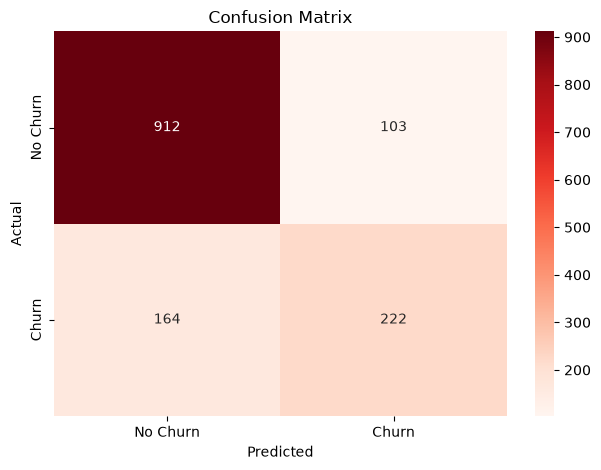

In [143]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
 
# plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

ROC-AUC Score: 0.8557


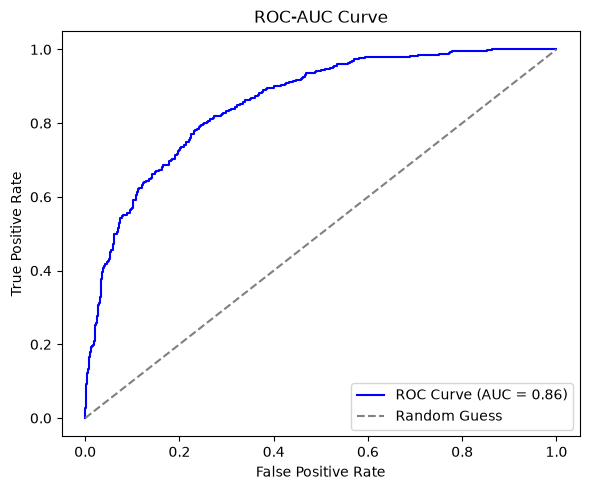

In [144]:
from sklearn.metrics import roc_curve, roc_auc_score

# get predicted probabilities for the positive class (Churn = 1)
y_proba = model.predict_proba(X_test)[:, 1]

# compute False Positive Rate, True Positive Rate at different thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# compute AUC score
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

# plot the ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.tight_layout()
plt.show()